In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az
from scipy.stats import invgamma, invwishart, gaussian_kde
from cavi import run_cavi
from ssvi import run_ssvi, calc_V_deltac, calc_mu_deltac, calc_D
from ssvi_2 import run_ssvi2, calc_V_beta02, calc_mu_beta02, calc_V_deltac2, calc_mu_deltac2, calc_D2
from gibbs import run_gibbs
from data_prep import prep_data

In [2]:
"""Data Loading"""

# selecting variables and dates
columns_wanted = ["lnipsa", "lncpi", "r-mkt", "lndem"]
start_date = "1987-01"
end_date = "1998-12"
# setting lags, number of variables, etc
L = 6
C = 5
T = len(pd.date_range(start=start_date, end=end_date, freq="MS"))
N = 4
N_w = 3
N_z = 3
L_w = [0,1]
L_z1 = [1,2]
L_z2 = [0,1]
K = N*L + N_w*len(L_w)
n_lag_z = len(L_z1)  # == len(L_z2)
Z_width = N_z * n_lag_z

# loading data
def load_and_filter(path, columns_wanted):
    df = pd.read_csv(path, index_col=0)
    df.index = pd.to_datetime(df.index, format="%Y-%m")
    df = df[columns_wanted]
    load_start = pd.Timestamp(start_date) - pd.DateOffset(months=L)
    df = df.loc[load_start:end_date]
    return df


fin = load_and_filter("Jarocinski Data/mj-data/2008-euro/finland.csv", columns_wanted)
por = load_and_filter("Jarocinski Data/mj-data/2008-euro/portugal.csv", columns_wanted)
ita = load_and_filter("Jarocinski Data/mj-data/2008-euro/italy.csv", columns_wanted)
spa = load_and_filter("Jarocinski Data/mj-data/2008-euro/spain.csv", columns_wanted)
fra = load_and_filter("Jarocinski Data/mj-data/2008-euro/france.csv", columns_wanted)

wor = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["ffr", "lnoil-eur", "lnnfd-eur"])
ger1 = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["lnipsa-ger"])
ger2 = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["r-mkt-ger", "lneur-usd"])

Y = np.stack([fin.values, por.values, ita.values, spa.values, fra.values], axis=0)
W = wor.values
Z1 = ger1.values
Z2 = ger2.values

In [3]:
"""Data Preprocessing"""

cavi_pack, ssvi_pack, gibbs_pack = prep_data(Y, W, Z1, Z2, C, N, N_w, T, K, Z_width, L, L_w, L_z1, L_z2)

In [ ]:
"""Simulated Data Generation (unused for now)"""
"""
T, C, N, L, W = 100, 6, 3, 2, 1
K = N*L + W
T_sim = T + L

def companion(B, N, L):
    K = N * L
    C = np.zeros((K, K))
    C[:N, :] = B[:, :K]  # exclude w column
    C[N:, :-N] = np.eye(N * (L - 1))
    return C

betas = np.random.normal(0.2, 0.3, size=(C, N, K))
for c in range(C):
    comp = companion(betas[c], N, L)
    radius = np.max(np.abs(np.linalg.eigvals(comp)))
    if radius >= 1:
        betas[c] *= 0.8 / radius

gamma = np.zeros((C, N))
for c in range(C):
    gamma[c] = np.random.normal(c * 0.2 * (-1)**c, 0.1 + c * 0.05, size=N)

# innovations
innovations = np.zeros((T_sim, C, N))
for c in range(C):
    A = np.random.randn(N, N) * 0.1
    Sigma = A @ A.T + np.eye(N) * 0.01
    innovations[:, c, :] = np.random.multivariate_normal(np.zeros(N), Sigma, size=T_sim)

# exogenous variables
z = np.zeros(T_sim)
for t in range(1, T_sim):
    z[t] = 0.7*z[t-1] + np.random.randn()

w = np.zeros(T_sim)
for t in range(1, T_sim):
    w[t] = 0.3*w[t-1] + np.random.randn()

# simulate
Y = np.random.randn(T_sim, C, N)
for t in range(L, T_sim):
    for c in range(C):
        lags = np.concatenate([Y[t-1, c, :], Y[t-2, c, :], [w[t-1]]])
        Y[t, c, :] = betas[c] @ lags + gamma[c]*z[t-1] + innovations[t, c, :]
"""

In [4]:
"""Running CAVI"""
results_cavi, ELBO_cavi = run_cavi(cavi_pack, Z_width, C, N, K, T)

In [5]:
"""Running SSVI"""
results_ssvi, ELBO_ssvi = run_ssvi(ssvi_pack, Z_width, C, N, K, T, n_steps=1000, step_size = 0.01, n_burnin = 100)

In [6]:
"""Running SSVI2"""
results_ssvi2, ELBO_ssvi2 = run_ssvi2(ssvi_pack, Z_width, C, N, K, T, n_steps=1000, step_size = 0.01, n_burnin = 100)

Running SSVI with step_size=0.001
Running SSVI with step_size=0.01
Running SSVI with step_size=0.002
Running SSVI with step_size=0.035
0.001 any NaN/inf: False
0.01 any NaN/inf: False
0.002 any NaN/inf: False
0.035 any NaN/inf: False


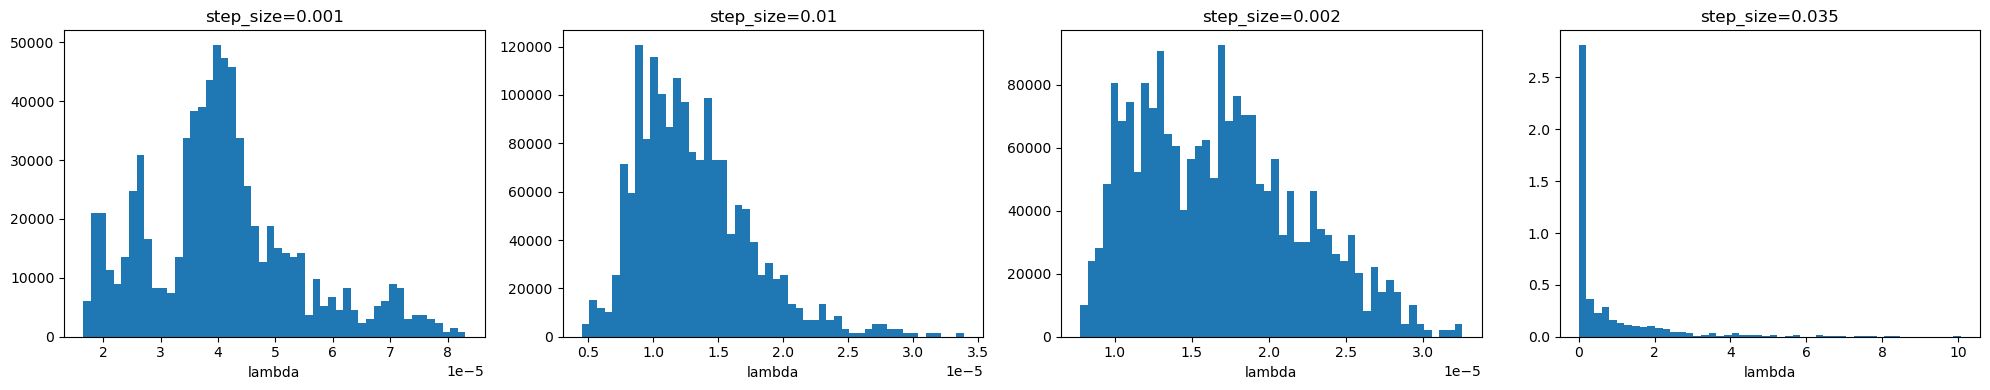

0.001 3.5526356233213265
0.01 60.30123582065268
0.002 7.4817988986553985
0.035 3000.0


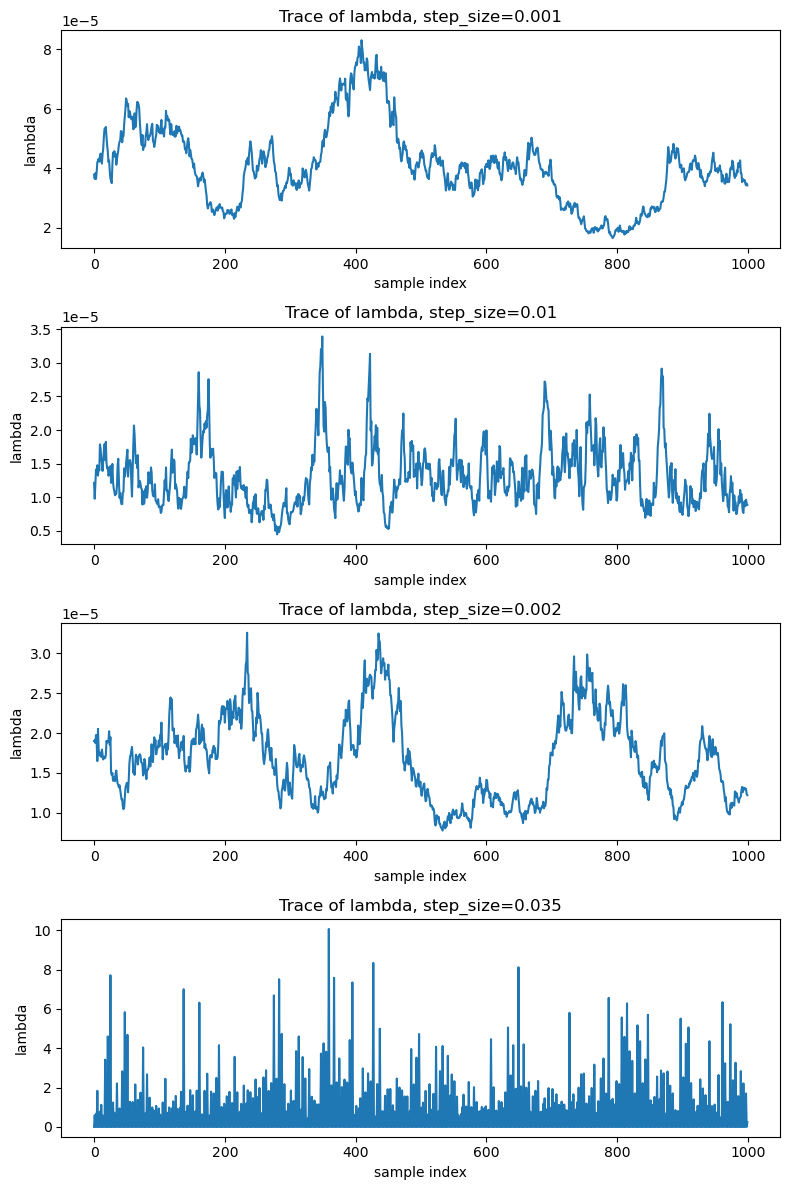

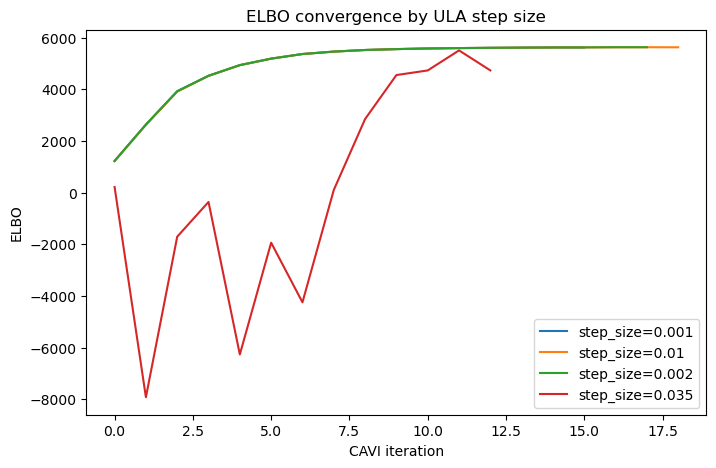

In [46]:
step_sizes = [0.001, 0.01, 0.002, 0.035]
results_by_step = {}

for ss in step_sizes:
    print(f"Running SSVI with step_size={ss}")
    results, ELBO = run_ssvi(ssvi_pack, Z_width, C, N, K, T, n_steps=1000, step_size=ss, n_burnin=100)
    results_by_step[ss] = {'results': results, 'ELBO': ELBO}

for ss in step_sizes:
    q_lambda = results_by_step[ss]['results']['q_lambda']
    print(ss, "any NaN/inf:", np.any(~np.isfinite(q_lambda)))

# Plot q*(lambda) histograms
fig, axes = plt.subplots(1, len(step_sizes), figsize=(5*len(step_sizes), 4))
for ax, ss in zip(axes, step_sizes):
    ax.hist(results_by_step[ss]['results']['q_lambda'], bins=50, density=True)
    ax.set_title(f"step_size={ss}")
    ax.set_xlabel("lambda")
plt.tight_layout()
plt.show()

for ss in step_sizes:
    log_q = np.log(results_by_step[ss]['results']['q_lambda'])
    ess = az.ess(log_q[np.newaxis, :])
    print(ss, float(ess))

#plot q*(lambda) traceplots
fig, axes = plt.subplots(len(step_sizes), 1, figsize=(8, 3*len(step_sizes)), sharex=False)

for ax, ss in zip(axes, step_sizes):
    q_lambda = results_by_step[ss]['results']['q_lambda']
    ax.plot(q_lambda)
    ax.set_title(f"Trace of lambda, step_size={ss}")
    ax.set_xlabel("sample index")
    ax.set_ylabel("lambda")

plt.tight_layout()
plt.show()

# Plot ELBO convergence
plt.figure(figsize=(8,5))
for ss in step_sizes:
    plt.plot(results_by_step[ss]['ELBO'], label=f"step_size={ss}")
plt.xlabel("CAVI iteration")
plt.ylabel("ELBO")
plt.legend()
plt.title("ELBO convergence by ULA step size")
plt.show()

In [12]:
"""Running Gibbs"""
results_gibbs, ess, rhat = run_gibbs(gibbs_pack, C, N, K, Z_width, T)

In [12]:
"""UQF Calculation"""

# get true covariance from Gibbs
cov_true = []
for c in range(C):
    delta_c_draws = np.array([results_gibbs["delta_c"][t][c] for t in range(len(results_gibbs["delta_c"]))])
    V_deltac_true = np.cov(delta_c_draws.T)
    cov_true.append(V_deltac_true)

# get specific part of covariance matrix from CAVI (only actual coefficients)
idx_deltac = cavi_pack["idx_deltac"]
size_deltac = cavi_pack["size_deltac"]
size_gammac = cavi_pack["size_gammac"]

V_delta = results_cavi["V_delta"]
cov_cavi = []
for c in range(C):
    start = idx_deltac[c]
    V_deltac_cavi = V_delta[start:start + size_deltac, start:start + size_deltac]
    cov_cavi.append(V_deltac_cavi)

# UQF calculation
def UQF(cov_true, cov_est):
    inv_cov_est = np.linalg.inv(cov_est)
    joint = cov_true @ inv_cov_est
    max_eigenvalue = np.max(np.linalg.eigvalsh(joint))

    return 1/max_eigenvalue

UQFs_cavi = [UQF(cov_true[c], cov_cavi[c]) for c in range(C)]

UQFs_cavi

[np.float64(0.002829472233248242),
 np.float64(0.003776702794841959),
 np.float64(0.0028133016929086626),
 np.float64(0.0031348221904563046),
 np.float64(0.005194621134353217)]

In [8]:
"""Getting samples from CAVI output"""
mu_delta, V_delta, v_bar, s_bar, S_bar_sigma = results_cavi.values()

idx_deltac = cavi_pack["idx_deltac"]
size_deltac = cavi_pack["size_deltac"]
size_gammac = cavi_pack["size_gammac"]

n_samples = 10000

# --- delta samples (beta_0, beta_c, gamma_c, delta_c all come from this) ---
L = np.linalg.cholesky(V_delta)
deltas = mu_delta + (L @ np.random.normal(size=(len(mu_delta), n_samples))).T  # (n_samples, size_delta)

beta_0_samples = deltas[:, :idx_deltac[0]]  # (n_samples, size_beta0)

beta_c_samples = [deltas[:, idx_deltac[c]:idx_deltac[c] + N*K] for c in range(C)]              # list of (n_samples, N*K)
gamma_c_samples = [deltas[:, idx_deltac[c] + N*K:idx_deltac[c] + N*K + size_gammac] for c in range(C)]  # list of (n_samples, size_gammac)
delta_c_samples = [deltas[:, idx_deltac[c]:idx_deltac[c] + size_deltac] for c in range(C)]     # list of (n_samples, size_deltac)

# --- lambda samples (cheap, vectorize trivially) ---
lam_samples = invgamma.rvs(s_bar/2, scale=v_bar/2, size=n_samples)

# --- Sigma_c samples (vectorized per country via scipy's size argument) ---
Sigma_c_samples = [invwishart.rvs(T, S_bar_sigma[c], size=n_samples) for c in range(C)]  # each: (n_samples, N, N)

# --- assemble into the same dict structure as before ---
cavi_samples = {
    'beta_0': list(beta_0_samples),
    'lam': list(lam_samples),
    'beta_c': [[beta_c_samples[c][n] for c in range(C)] for n in range(n_samples)],
    'gamma_c': [[gamma_c_samples[c][n] for c in range(C)] for n in range(n_samples)],
    'delta_c': [[delta_c_samples[c][n] for c in range(C)] for n in range(n_samples)],
    'Sigma_c': [[Sigma_c_samples[c][n] for c in range(C)] for n in range(n_samples)],
}

In [9]:
mu_beta0, V_beta0, q_lambda_chain, S_bar_sigma = results_ssvi.values()
mu_sigma_inv = [T * np.linalg.inv(S_bar_sigma[c]) for c in range(C)]  
Y, F, FF, idx_deltac, size_deltac, Pc, Lambda_inv, Lambda_inv_sum = ssvi_pack.values()

n_samples = 10000

# lambda: sample from a KDE fit to the converged ULA chain (log-space, since lambda > 0)
lam_chain = np.asarray(q_lambda_chain)
kde_lam = gaussian_kde(np.log(lam_chain))
lam_samples = np.exp(kde_lam.resample(n_samples).flatten())

# beta_0: independent draw, paired with lam_samples by index
L_beta0 = np.linalg.cholesky(V_beta0)
beta_0_samples = mu_beta0 + (L_beta0 @ np.random.normal(size=(len(mu_beta0), n_samples))).T  # (n_samples, size_beta0)

# V_deltac, mu_deltac: both batched over the same (lam, beta0) pairs
V_deltac  = calc_V_deltac(lam_samples, mu_sigma_inv, FF, Lambda_inv, size_deltac, Pc, C, N, K)
mu_deltac = calc_mu_deltac(lam_samples, beta_0_samples, V_deltac, mu_sigma_inv, Y, F, Lambda_inv, size_deltac, Pc, C, N, K)

delta_c_samples_arr = np.empty((n_samples, C, size_deltac))
for c in range(C):
    L_c = np.linalg.cholesky(V_deltac[c])                 # (n_samples, size_deltac, size_deltac)
    z = np.random.normal(size=(n_samples, size_deltac))
    delta_c_samples_arr[:, c, :] = mu_deltac[c] + np.einsum('nij,nj->ni', L_c, z)

beta_c_samples_arr  = delta_c_samples_arr[:, :, :N*K]
gamma_c_samples_arr = delta_c_samples_arr[:, :, N*K:]

Sigma_c_samples = np.stack(
    [invwishart.rvs(T, S_bar_sigma[c], size=n_samples) for c in range(C)], axis=1
)

ssvi_samples = {
    'beta_0':  list(beta_0_samples),
    'lam':     list(lam_samples),
    'beta_c':  list(beta_c_samples_arr),
    'gamma_c': list(gamma_c_samples_arr),
    'delta_c': list(delta_c_samples_arr),
    'Sigma_c': list(Sigma_c_samples),
}

In [10]:
q_lambda_chain, S_bar_sigma = results_ssvi2.values()
mu_sigma_inv = [T * np.linalg.inv(S_bar_sigma[c]) for c in range(C)]
Y, F, FF, idx_deltac, size_deltac, Pc, Lambda_inv, Lambda_inv_sum = ssvi_pack.values()

n_samples = 10000

# lambda: sample from a KDE fit to the converged ULA chain (log-space, since lambda > 0)
lam_chain = np.asarray(q_lambda_chain)
kde_lam = gaussian_kde(np.log(lam_chain))
lam_samples = np.exp(kde_lam.resample(n_samples).flatten())

# V_deltac(lambda), computed once and reused for both beta0 and delta_c
V_deltac = calc_V_deltac2(lam_samples, mu_sigma_inv, FF, Lambda_inv, size_deltac, Pc, C, N, K)

# beta_0 | lambda
V_beta0  = calc_V_beta02(lam_samples, V_deltac, Lambda_inv, Lambda_inv_sum, C, N, K)
mu_beta0 = calc_mu_beta02(lam_samples, V_deltac, mu_sigma_inv, V_beta0, Y, F, Lambda_inv, Pc, C, N, K)

size_beta0 = mu_beta0.shape[-1]
L_beta0 = np.linalg.cholesky(V_beta0)
z_beta0 = np.random.normal(size=(n_samples, size_beta0))
beta_0_samples = mu_beta0 + np.einsum('nij,nj->ni', L_beta0, z_beta0)

# delta_c | lambda, beta0
mu_deltac = calc_mu_deltac2(lam_samples, beta_0_samples, V_deltac, mu_sigma_inv, Y, F, Lambda_inv, size_deltac, Pc, C, N, K)

delta_c_samples_arr = np.empty((n_samples, C, size_deltac))
for c in range(C):
    L_c = np.linalg.cholesky(V_deltac[c])
    z = np.random.normal(size=(n_samples, size_deltac))
    delta_c_samples_arr[:, c, :] = mu_deltac[c] + np.einsum('nij,nj->ni', L_c, z)

beta_c_samples_arr  = delta_c_samples_arr[:, :, :N*K]
gamma_c_samples_arr = delta_c_samples_arr[:, :, N*K:]

Sigma_c_samples = np.stack(
    [invwishart.rvs(T, S_bar_sigma[c], size=n_samples) for c in range(C)], axis=1
)

ssvi2_samples = {
    'beta_0':  list(beta_0_samples),
    'lam':     list(lam_samples),
    'beta_c':  list(beta_c_samples_arr),
    'gamma_c': list(gamma_c_samples_arr),
    'delta_c': list(delta_c_samples_arr),
    'Sigma_c': list(Sigma_c_samples),
}

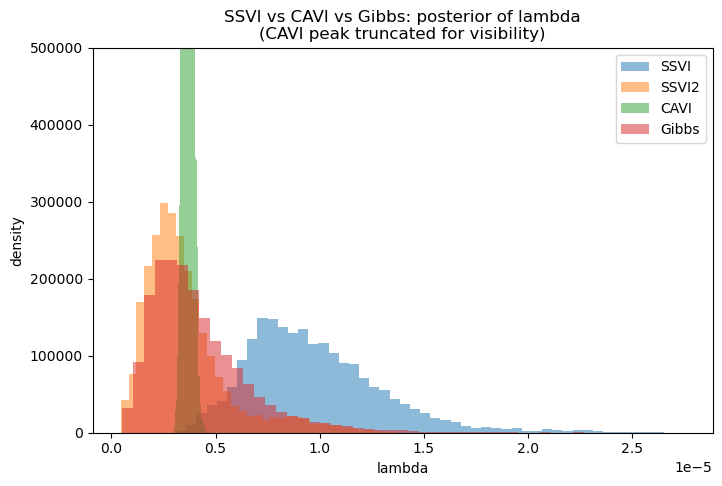

In [13]:
plt.figure(figsize=(8,5))
plt.hist(ssvi_samples['lam'], bins=50, density=True, alpha=0.5, label='SSVI')
plt.hist(ssvi2_samples['lam'], bins=50, density=True, alpha=0.5, label='SSVI2')
plt.hist(cavi_samples['lam'], bins=50, density=True, alpha=0.5, label='CAVI')
plt.hist(results_gibbs['lam'], bins=50, density=True, alpha=0.5, label='Gibbs')

plt.ylim(0, 500000)  # cap the y-axis so CAVI's spike is cut off
plt.xlabel('lambda')
plt.ylabel('density')
plt.legend()
plt.title('SSVI vs CAVI vs Gibbs: posterior of lambda\n(CAVI peak truncated for visibility)')
plt.show()

In [14]:
"""Accuracy Measure (Faes et al. 2011, ter Steege eq. 20) — vectorized + parallel"""

import numpy as np
from scipy.stats import gaussian_kde
from joblib import Parallel, delayed

def faes_accuracy(vi_samples, gibbs_samples, positive_support=False, grid_size=500):
    vi_samples = np.asarray(vi_samples)
    gibbs_samples = np.asarray(gibbs_samples)

    if positive_support:
        vi_samples = np.log(vi_samples)
        gibbs_samples = np.log(gibbs_samples)

    kde_q = gaussian_kde(vi_samples)
    kde_p = gaussian_kde(gibbs_samples)

    # Bounds per paper: smallest/largest value across BOTH sample sets, no padding
    lo = min(vi_samples.min(), gibbs_samples.min())
    hi = max(vi_samples.max(), gibbs_samples.max())
    grid = np.linspace(lo, hi, grid_size)

    iae = np.trapezoid(np.abs(kde_q(grid) - kde_p(grid)), grid)
    return 100 * (1 - 0.5 * iae)


def _faes_grid(cavi_arr, gibbs_arr, positive_support=False, n_jobs=-1):
    """
    cavi_arr, gibbs_arr: shape (T, C, D) — draws x countries x scalar-dim.
    Returns shape (C, D) of accuracy scores, computed in parallel over (c,d) pairs.
    """
    T, C, D = cavi_arr.shape
    pairs = [(c, d) for c in range(C) for d in range(D)]

    results = Parallel(n_jobs=n_jobs)(
        delayed(faes_accuracy)(cavi_arr[:, c, d], gibbs_arr[:, c, d], positive_support)
        for c, d in pairs
    )
    out = np.empty((C, D))
    for (c, d), val in zip(pairs, results):
        out[c, d] = val
    return out


def _faes_vec(cavi_arr, gibbs_arr, positive_support=False, n_jobs=-1):
    """
    cavi_arr, gibbs_arr: shape (T, D) — draws x scalar-dim (no country axis).
    Returns shape (D,) of accuracy scores.
    """
    T, D = cavi_arr.shape
    results = Parallel(n_jobs=n_jobs)(
        delayed(faes_accuracy)(cavi_arr[:, d], gibbs_arr[:, d], positive_support)
        for d in range(D)
    )
    return np.array(results)


# --- Convert nested lists to arrays ONCE, upfront ---
beta_c_cavi  = np.array(cavi_samples['beta_c'])          # (T, C, N*K)
beta_c_gibbs = np.array(results_gibbs['beta_c'])          # (T, C, N*K)

gamma_c_cavi  = np.array(cavi_samples['gamma_c'])         # (T, C, N*n_zc)
gamma_c_gibbs = np.array(results_gibbs['gamma_c'])        # (T, C, N*n_zc)

beta_0_cavi  = np.array(cavi_samples['beta_0'])           # (T, N*K)
beta_0_gibbs = np.array(results_gibbs['beta_0'])          # (T, N*K)

# Sigma_c diagonals: extract diag once, vectorized, before parallel calls
Sigma_c_cavi_full  = np.array(cavi_samples['Sigma_c'])    # (T, C, N, N)
Sigma_c_gibbs_full = np.array(results_gibbs['Sigma_c'])   # (T, C, N, N)
Sigma_c_cavi  = np.diagonal(Sigma_c_cavi_full,  axis1=2, axis2=3)   # (T, C, N)
Sigma_c_gibbs = np.diagonal(Sigma_c_gibbs_full, axis1=2, axis2=3)   # (T, C, N)

# --- Compute ---
results_faes_cavi = {}
results_faes_cavi['beta_c']   = _faes_grid(beta_c_cavi, beta_c_gibbs)
results_faes_cavi['gamma_c']  = _faes_grid(gamma_c_cavi, gamma_c_gibbs)
results_faes_cavi['beta_0']   = _faes_vec(beta_0_cavi, beta_0_gibbs)
results_faes_cavi['lam']      = faes_accuracy(cavi_samples['lam'], results_gibbs['lam'], positive_support=True)
results_faes_cavi['Sigma_c']  = _faes_grid(Sigma_c_cavi, Sigma_c_gibbs, positive_support=True)

In [18]:
# --- Convert nested lists to arrays ONCE, upfront ---
beta_c_ssvi  = np.array(ssvi_samples['beta_c'])          # (T, C, N*K)

gamma_c_ssvi  = np.array(ssvi_samples['gamma_c'])         # (T, C, N*n_zc)

beta_0_ssvi  = np.array(ssvi_samples['beta_0'])           # (T, N*K)

# Sigma_c diagonals: extract diag once, vectorized, before parallel calls
Sigma_c_ssvi_full  = np.array(ssvi_samples['Sigma_c'])    # (T, C, N, N)
Sigma_c_ssvi  = np.diagonal(Sigma_c_ssvi_full,  axis1=2, axis2=3)   # (T, C, N)

# --- Compute ---
results_faes_ssvi = {}
results_faes_ssvi['beta_c']   = _faes_grid(beta_c_ssvi, beta_c_gibbs)
results_faes_ssvi['gamma_c']  = _faes_grid(gamma_c_ssvi, gamma_c_gibbs)
results_faes_ssvi['beta_0']   = _faes_vec(beta_0_ssvi, beta_0_gibbs)
results_faes_ssvi['lam']      = faes_accuracy(ssvi_samples['lam'], results_gibbs['lam'], positive_support=True)
results_faes_ssvi['Sigma_c']  = _faes_grid(Sigma_c_ssvi, Sigma_c_gibbs, positive_support=True)

In [15]:
# --- Convert nested lists to arrays ONCE, upfront ---
beta_c_ssvi2  = np.array(ssvi2_samples['beta_c'])          # (T, C, N*K)

gamma_c_ssvi2  = np.array(ssvi2_samples['gamma_c'])         # (T, C, N*n_zc)

beta_0_ssvi2  = np.array(ssvi2_samples['beta_0'])           # (T, N*K)

# Sigma_c diagonals: extract diag once, vectorized, before parallel calls
Sigma_c_ssvi2_full  = np.array(ssvi2_samples['Sigma_c'])    # (T, C, N, N)
Sigma_c_ssvi2  = np.diagonal(Sigma_c_ssvi2_full,  axis1=2, axis2=3)   # (T, C, N)

# --- Compute ---
results_faes_ssvi2 = {}
results_faes_ssvi2['beta_c']   = _faes_grid(beta_c_ssvi2, beta_c_gibbs)
results_faes_ssvi2['gamma_c']  = _faes_grid(gamma_c_ssvi2, gamma_c_gibbs)
results_faes_ssvi2['beta_0']   = _faes_vec(beta_0_ssvi2, beta_0_gibbs)
results_faes_ssvi2['lam']      = faes_accuracy(ssvi2_samples['lam'], results_gibbs['lam'], positive_support=True)
results_faes_ssvi2['Sigma_c']  = _faes_grid(Sigma_c_ssvi2, Sigma_c_gibbs, positive_support=True)

C:\Users\krrol\AppData\Local\Temp\ipykernel_17788\66123232.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([results_faes_cavi['beta_c'][c] for c in range(C)], labels=country_labels)
C:\Users\krrol\AppData\Local\Temp\ipykernel_17788\66123232.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([results_faes_cavi['gamma_c'][c] for c in range(C)], labels=country_labels)
C:\Users\krrol\AppData\Local\Temp\ipykernel_17788\66123232.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot([results_faes_cavi['Sigma_c'][c] for c in range(C)], labels=country_labels)
C:\Use

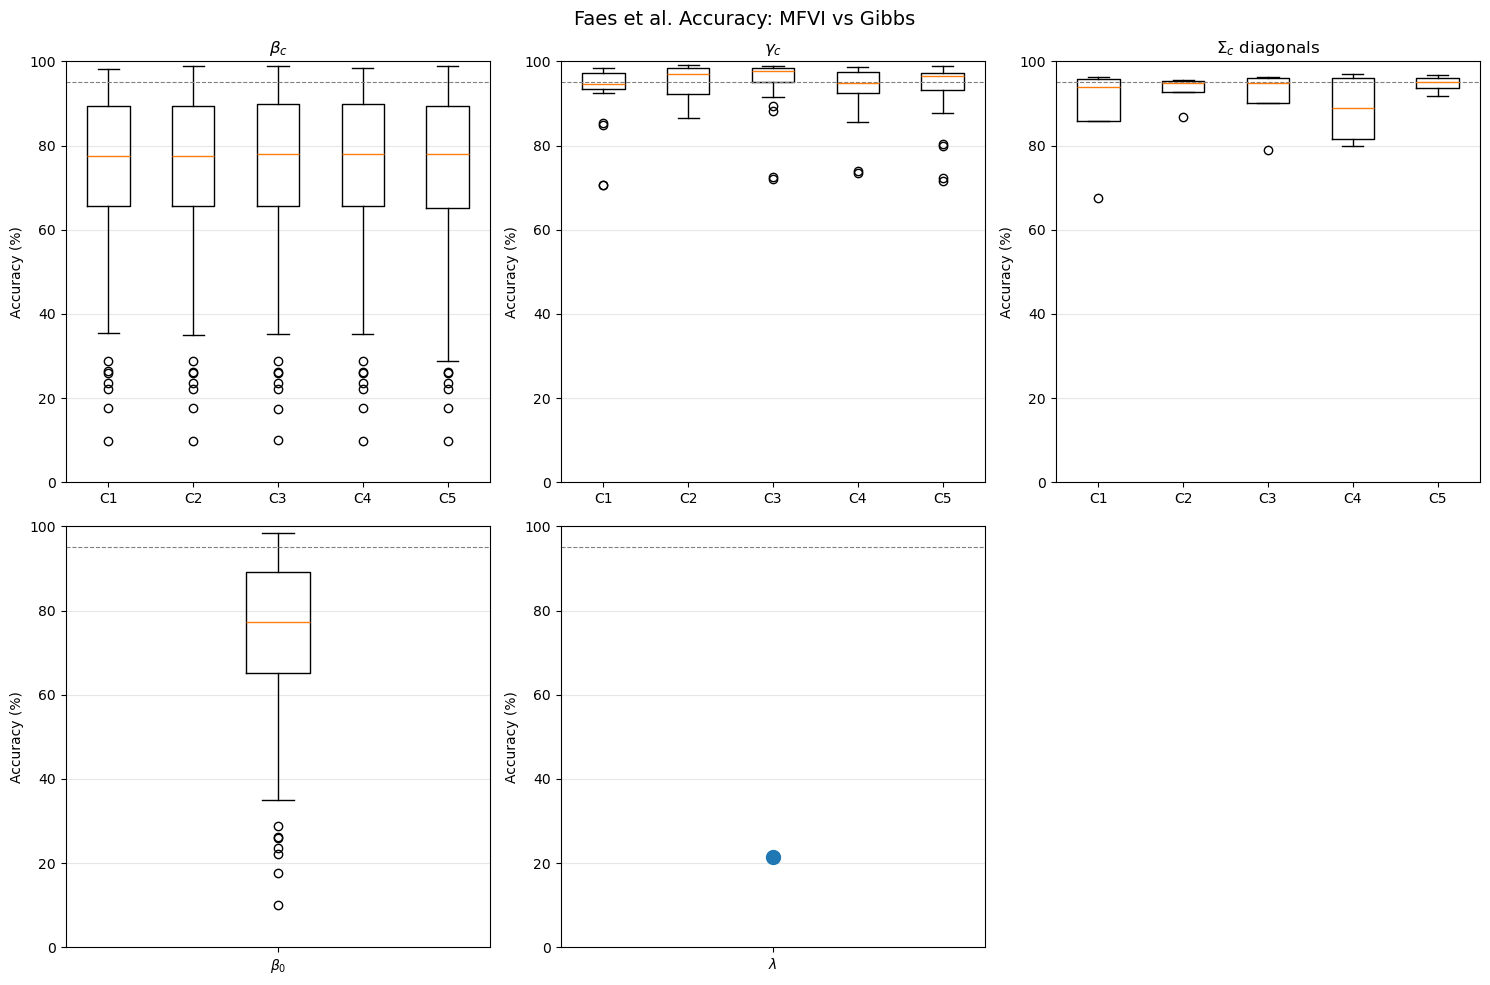

In [16]:
"""Boxplots of Accuracy"""

country_labels = [f'C{c+1}' for c in range(C)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# beta_c: one box per country
axes[0, 0].boxplot([results_faes_cavi['beta_c'][c] for c in range(C)], labels=country_labels)
axes[0, 0].set_title(r'$\beta_c$')
axes[0, 0].set_ylabel('Accuracy (%)')

# gamma_c: one box per country
axes[0, 1].boxplot([results_faes_cavi['gamma_c'][c] for c in range(C)], labels=country_labels)
axes[0, 1].set_title(r'$\gamma_c$')
axes[0, 1].set_ylabel('Accuracy (%)')

# Sigma_c diagonals: one box per country
axes[0, 2].boxplot([results_faes_cavi['Sigma_c'][c] for c in range(C)], labels=country_labels)
axes[0, 2].set_title(r'$\Sigma_c$ diagonals')
axes[0, 2].set_ylabel('Accuracy (%)')

# beta_0: single box over all N*K coefficients
axes[1, 0].boxplot([results_faes_cavi['beta_0']], labels=[r'$\beta_0$'])
axes[1, 0].set_ylabel('Accuracy (%)')

# lambda: single value, shown as a point
axes[1, 1].scatter([1], [results_faes_cavi['lam']], s=100, zorder=5)
axes[1, 1].set_xlim(0.5, 1.5)
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels([r'$\lambda$'])
axes[1, 1].set_ylabel('Accuracy (%)')

axes[1, 2].set_visible(False)

for ax in axes.flat:
    if ax.get_visible():
        ax.set_ylim(0, 100)
        ax.axhline(y=95, color='grey', linestyle='--', linewidth=0.8)
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Faes et al. Accuracy: MFVI vs Gibbs', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\krrol\AppData\Local\Temp\ipykernel_17788\4095242518.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([results_faes_ssvi['beta_c'][c] for c in range(C)], labels=country_labels)
C:\Users\krrol\AppData\Local\Temp\ipykernel_17788\4095242518.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([results_faes_ssvi['gamma_c'][c] for c in range(C)], labels=country_labels)
C:\Users\krrol\AppData\Local\Temp\ipykernel_17788\4095242518.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot([results_faes_ssvi['Sigma_c'][c] for c in range(C)], labels=country_labels)


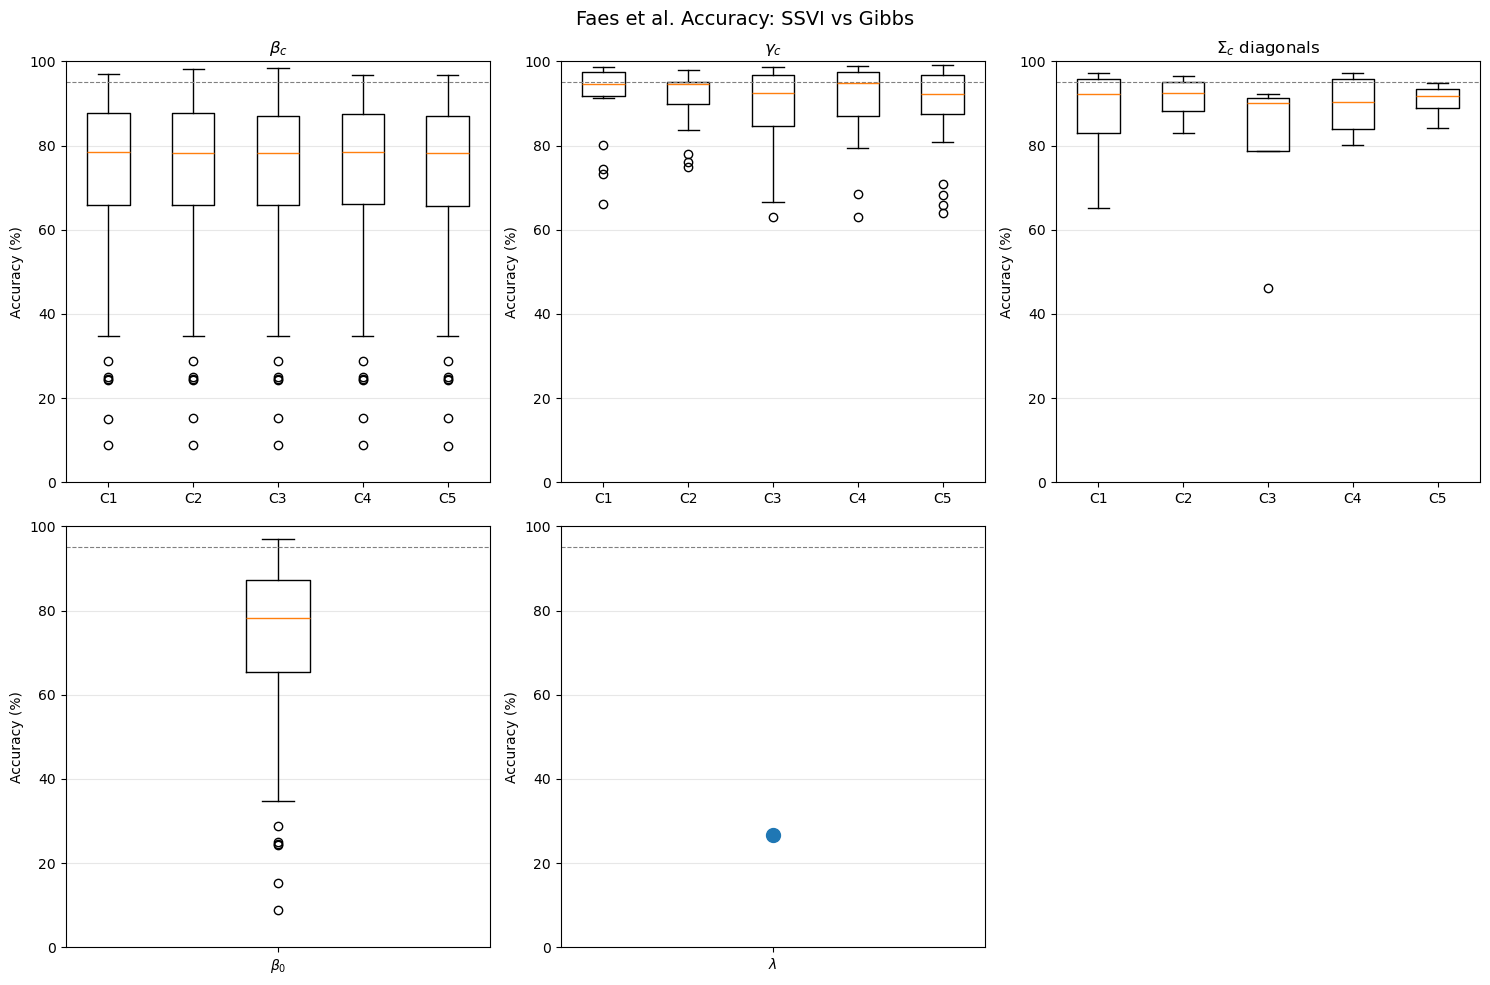

In [19]:
"""Boxplots of Accuracy"""

country_labels = [f'C{c+1}' for c in range(C)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# beta_c: one box per country
axes[0, 0].boxplot([results_faes_ssvi['beta_c'][c] for c in range(C)], labels=country_labels)
axes[0, 0].set_title(r'$\beta_c$')
axes[0, 0].set_ylabel('Accuracy (%)')

# gamma_c: one box per country
axes[0, 1].boxplot([results_faes_ssvi['gamma_c'][c] for c in range(C)], labels=country_labels)
axes[0, 1].set_title(r'$\gamma_c$')
axes[0, 1].set_ylabel('Accuracy (%)')

# Sigma_c diagonals: one box per country
axes[0, 2].boxplot([results_faes_ssvi['Sigma_c'][c] for c in range(C)], labels=country_labels)
axes[0, 2].set_title(r'$\Sigma_c$ diagonals')
axes[0, 2].set_ylabel('Accuracy (%)')

# beta_0: single box over all N*K coefficients
axes[1, 0].boxplot([results_faes_ssvi['beta_0']], labels=[r'$\beta_0$'])
axes[1, 0].set_ylabel('Accuracy (%)')

# lambda: single value, shown as a point
axes[1, 1].scatter([1], [results_faes_ssvi['lam']], s=100, zorder=5)
axes[1, 1].set_xlim(0.5, 1.5)
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels([r'$\lambda$'])
axes[1, 1].set_ylabel('Accuracy (%)')

axes[1, 2].set_visible(False)

for ax in axes.flat:
    if ax.get_visible():
        ax.set_ylim(0, 100)
        ax.axhline(y=95, color='grey', linestyle='--', linewidth=0.8)
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Faes et al. Accuracy: SSVI vs Gibbs', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\krrol\AppData\Local\Temp\ipykernel_17788\2035923886.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([results_faes_ssvi2['beta_c'][c] for c in range(C)], labels=country_labels)
C:\Users\krrol\AppData\Local\Temp\ipykernel_17788\2035923886.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([results_faes_ssvi2['gamma_c'][c] for c in range(C)], labels=country_labels)
C:\Users\krrol\AppData\Local\Temp\ipykernel_17788\2035923886.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot([results_faes_ssvi2['Sigma_c'][c] for c in range(C)], labels=country_label

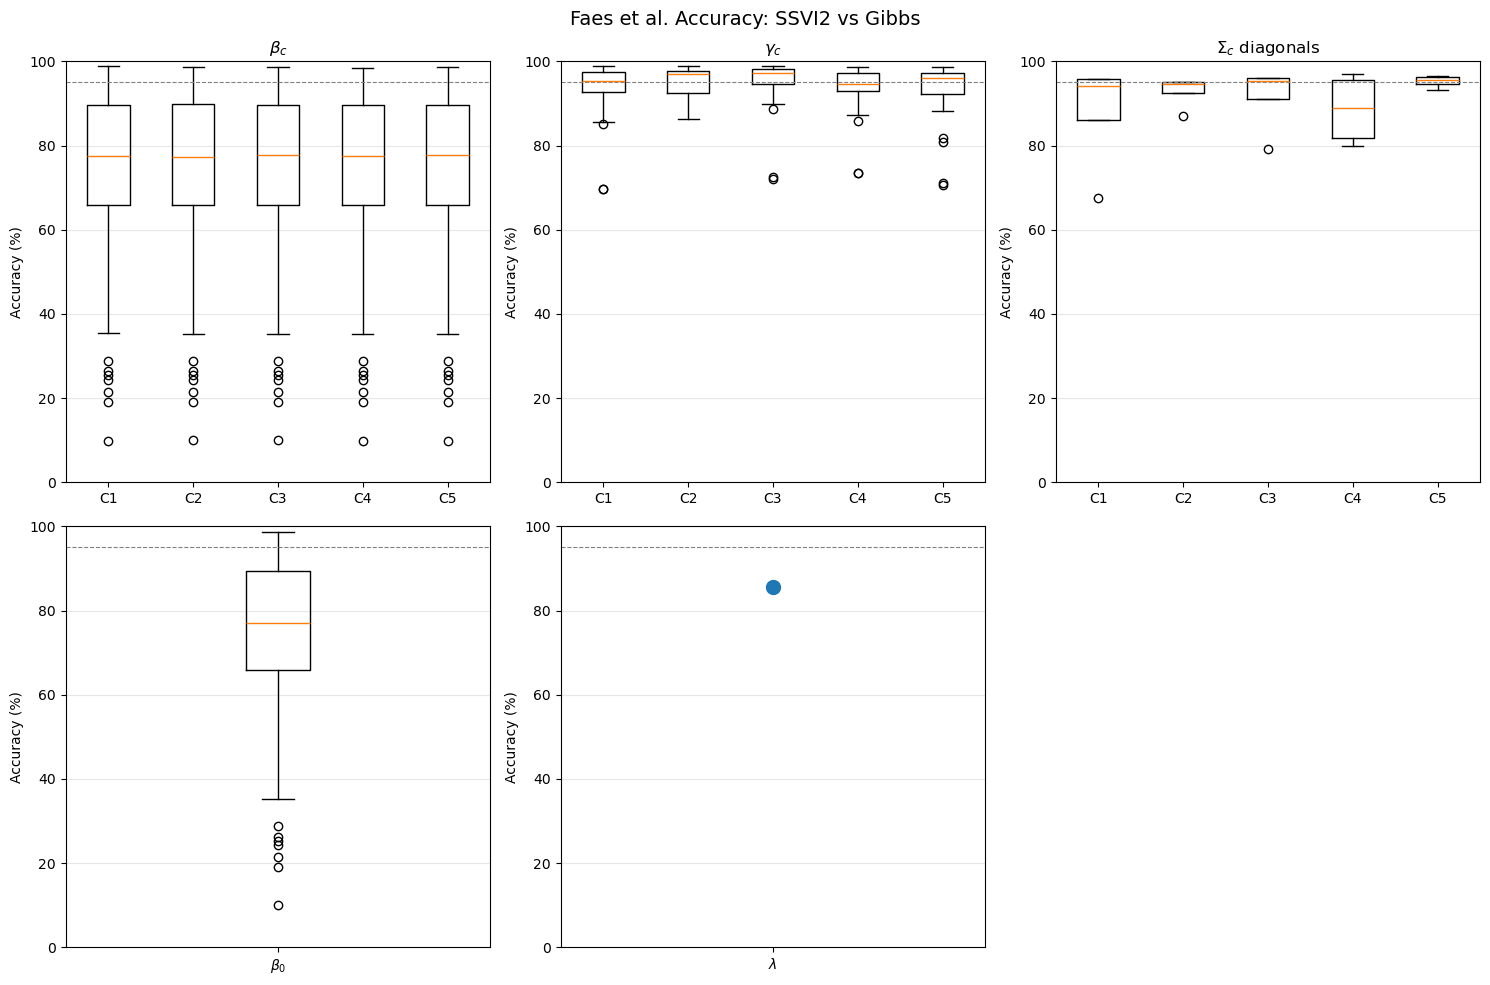

In [17]:
"""Boxplots of Accuracy"""

country_labels = [f'C{c+1}' for c in range(C)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# beta_c: one box per country
axes[0, 0].boxplot([results_faes_ssvi2['beta_c'][c] for c in range(C)], labels=country_labels)
axes[0, 0].set_title(r'$\beta_c$')
axes[0, 0].set_ylabel('Accuracy (%)')

# gamma_c: one box per country
axes[0, 1].boxplot([results_faes_ssvi2['gamma_c'][c] for c in range(C)], labels=country_labels)
axes[0, 1].set_title(r'$\gamma_c$')
axes[0, 1].set_ylabel('Accuracy (%)')

# Sigma_c diagonals: one box per country
axes[0, 2].boxplot([results_faes_ssvi2['Sigma_c'][c] for c in range(C)], labels=country_labels)
axes[0, 2].set_title(r'$\Sigma_c$ diagonals')
axes[0, 2].set_ylabel('Accuracy (%)')

# beta_0: single box over all N*K coefficients
axes[1, 0].boxplot([results_faes_ssvi2['beta_0']], labels=[r'$\beta_0$'])
axes[1, 0].set_ylabel('Accuracy (%)')

# lambda: single value, shown as a point
axes[1, 1].scatter([1], [results_faes_ssvi2['lam']], s=100, zorder=5)
axes[1, 1].set_xlim(0.5, 1.5)
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels([r'$\lambda$'])
axes[1, 1].set_ylabel('Accuracy (%)')

axes[1, 2].set_visible(False)

for ax in axes.flat:
    if ax.get_visible():
        ax.set_ylim(0, 100)
        ax.axhline(y=95, color='grey', linestyle='--', linewidth=0.8)
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Faes et al. Accuracy: SSVI2 vs Gibbs', fontsize=14)
plt.tight_layout()
plt.show()